In [1]:
import string
import time
from collections import defaultdict

import pulp

from rnapolis.common import BpSeq, Entry

brackets = "([{<" + string.ascii_uppercase
instances = []

for j in range(len(brackets)):
    entries = []

    for i in range(j + 1):
        entries.append(Entry(i + 1, "C", i + j + 2))
        entries.append(Entry(i + j + 2, "G", i + 1))

    bpseq = BpSeq(sorted(entries))
    instances.append(bpseq)


fcfs_times = []
solver_times = defaultdict(list)

instances = instances[:16]

for instance in instances:
    start_time = time.time()
    instance.fcfs
    fcfs_times.append(time.time() - start_time)

    for solver_name in pulp.listSolvers(onlyAvailable=True):
        if solver_name == "GLPK_CMD":
            continue

        solver = pulp.getSolver(solver_name, msg=False)
        start_time = time.time()
        instance.convert_to_dot_bracket(solver)
        solver_times[solver_name].append(time.time() - start_time)


print("FCFS times:", fcfs_times)
for solver_name in pulp.listSolvers(onlyAvailable=True):
    if solver_name == "GLPK_CMD":
        continue
    print(f"{solver_name} times:", solver_times[solver_name])

FCFS times: [4.315376281738281e-05, 2.7894973754882812e-05, 3.743171691894531e-05, 6.937980651855469e-05, 5.817413330078125e-05, 8.392333984375e-05, 7.009506225585938e-05, 5.340576171875e-05, 7.43865966796875e-05, 8.487701416015625e-05, 9.5367431640625e-05, 0.00010037422180175781, 0.00010752677917480469, 9.679794311523438e-05, 0.00010037422180175781, 0.00011301040649414062]
PULP_CBC_CMD times: [2.9802322387695312e-05, 0.003612518310546875, 0.004915714263916016, 0.006447553634643555, 0.008742809295654297, 0.015163421630859375, 0.02203655242919922, 0.031852006912231445, 0.04686260223388672, 0.06788444519042969, 0.11065840721130371, 0.2701878547668457, 0.5172040462493896, 0.9254910945892334, 1.2024261951446533, 1.967221736907959]
HiGHS_CMD times: [1.5020370483398438e-05, 0.003680706024169922, 0.015226602554321289, 0.013864278793334961, 0.016956329345703125, 0.016142845153808594, 0.018148422241210938, 0.020943164825439453, 0.022336959838867188, 0.02439570426940918, 0.02999281883239746, 0.0

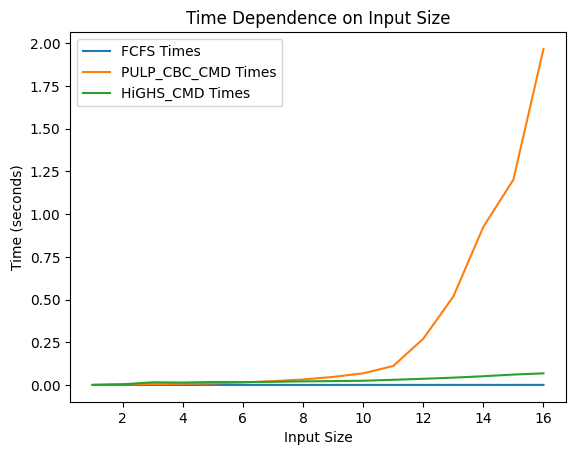

In [2]:
import matplotlib.pyplot as plt

input_sizes = [len(instance.entries) // 2 for instance in instances]

plt.plot(input_sizes, fcfs_times, label="FCFS Times")
for solver_name in pulp.listSolvers(onlyAvailable=True):
    if solver_name == "GLPK_CMD":
        continue
    plt.plot(input_sizes, solver_times[solver_name], label=f"{solver_name} Times")
plt.xlabel("Input Size")
plt.ylabel("Time (seconds)")
plt.title("Time Dependence on Input Size")
plt.legend()
plt.show()